Distanza specchi stimata dal fit: d = 0.4034 +/- 0.0038 cm
Spostamento D calcolato dalla luce: 18.73 um
Rapporto calibrazione (reale/nominale): 0.937


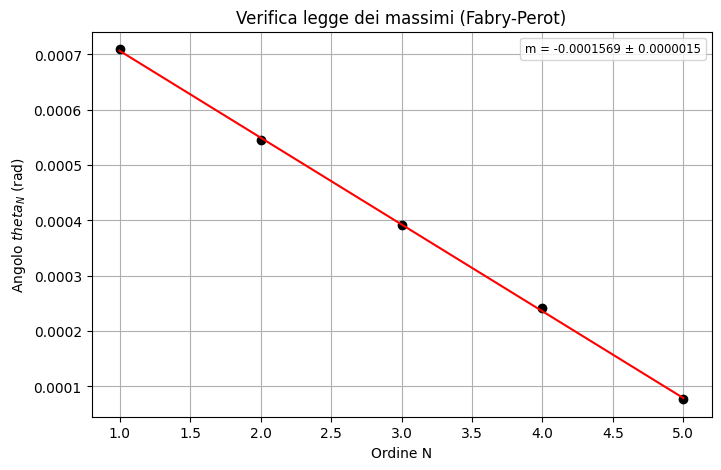

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D

# --- 1. FABRY-PEROT ---
L = 161.4 # cm (Distanza schermo)
diametri_medi = np.array([8.6, 7.536, 6.388, 5.014, 2.832]) # cm (da N=1 a N=5)
ordini_N = np.array([1, 2, 3, 4, 5]) 
lambda_he_ne = 632.8e-7 # cm (632.8 nm convertiti in cm)

# Calcolo degli angoli theta_N dai diametri
# r = diametro / 2 -> tan(theta) = r / L
raggi = diametri_medi / 2
theta_rad = np.arctan(raggi / L)
theta_N = theta_rad**2

# ---  FIT LINEARE (d come parametro libero) ---
# La pendenza m sarà uguale a lambda / d 
def modello_lineare(p, m, q):
    return m * p + q

# Fit dei dati (theta_N in funzione di N)
popt, pcov = curve_fit(modello_lineare, ordini_N, theta_N) 
m_fit, q_fit = popt

# Ricaviamo d dalla pendenza: d = lambda / m
d_fit = lambda_he_ne / np.abs(m_fit)
d_err = (np.sqrt(pcov[0,0]) / np.abs(m_fit)) * d_fit
print(f"Distanza specchi stimata dal fit: d = {d_fit:.4f} +/- {d_err:.4f} cm")

# --- 3. CALIBRAZIONE MICROMETRO ---
delta_N_medio = 59.2
# lo spostamento micrometro di 20 micron (0.002 cm)
delta_d_micrometro = 0.002 

# Calcolo Delta d reale 
delta_d_reale = (delta_N_medio * lambda_he_ne) / 2

print(f"Spostamento D calcolato dalla luce: {delta_d_reale*1e4:.2f} um")
print(f"Rapporto calibrazione (reale/nominale): {delta_d_reale/delta_d_micrometro:.3f}")

# --- 4. GRAFICO DEI DIAMETRI ---
plt.figure(figsize=(8, 5))
plt.plot(ordini_N, theta_N, 'ko', label='Dati Sperimentali')
plt.plot(ordini_N, modello_lineare(ordini_N, *popt), 'r-', label='Fit teorico')

custom_lines = [Line2D([0], [0], color = 'None', marker = None, lw = 0)
            ]
labels = [f'm = {m_fit:.7f} ± {np.sqrt(pcov[0,0]):.7f}']

plt.xlabel('Ordine N')
plt.ylabel('Angolo $theta_N$ (rad)')
plt.title('Verifica legge dei massimi (Fabry-Perot)')
plt.legend( fontsize = "small", handles = custom_lines, labels = labels, handlelength=0, handletextpad=0, loc = 'upper right')
plt.grid(True)
plt.show()

<>:50: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:51: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:50: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:51: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\NB05\AppData\Local\Temp\ipykernel_12764\1703830256.py:50: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel('Variazione di Pressione $\Delta P$ (mmHg)')
C:\Users\NB05\AppData\Local\Temp\ipykernel_12764\1703830256.py:51: SyntaxWarning: "\D" is an invalid escape sequ

Risultato Fit: k = 0.7720 +/- 0.0142
Coefficiente m = 8.14e-06 +/- 1.49e-07 mmHg^-1


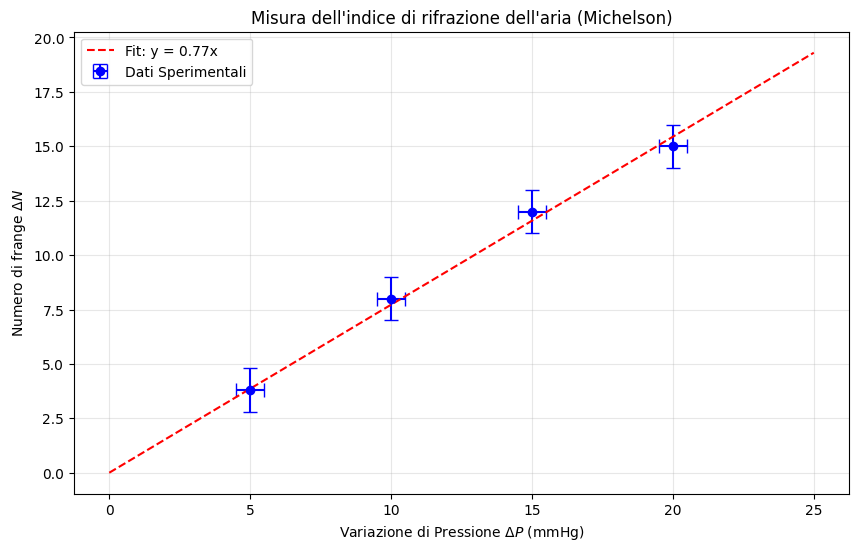

Pressione atmosferica considerata: 101.325 mmHg
Indice di rifrazione dell'aria calcolato (n): 1.000825 +/- 0.000015
Valore t-test: 70.25


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

# pressione 
pressur_diff = np.array([5,10, 15, 20]) 
fringe_counts = np.array([3.8,8.0, 12.0, 15.0]) # Esempio basato sulle tue medie

# Incertezze 
# Supponiamo un errore di 0.5 kPa sulla pressione e 1 frangia sul conteggio
delta_P_err = np.ones_like(pressur_diff) * 0.5
delta_N_err = np.ones_like(fringe_counts) * 1.0

# Costanti dell'esperimento
lambda_he_ne = 632.8e-7 # cm (632.8 nm)
d_cell = 3.0 # cm 

# --- 2. DEFINIZIONE DEL MODELLO DI FIT ---
# Dalla legge: 2 * d * m * DeltaP = DeltaN * lambda
# Possiamo scriverla come: DeltaN = (2 * d * m / lambda) * DeltaP
# Quindi il nostro fit sarà una retta y = k * x
def modello_lineare(x, k):
    return k * x

# --- 3. ESECUZIONE DEL FIT ---
# curve_fit restituisce i parametri ottimali (popt) e la matrice di covarianza (pcov)
popt, pcov = curve_fit(modello_lineare, pressur_diff, fringe_counts, sigma=delta_N_err)

k_ottimale = popt[0]
k_errore = np.sqrt(pcov[0,0])

# Calcolo di m (pendenza dell'indice di rifrazione)
# m = k * lambda / (2 * d)
m_calcolato = k_ottimale * lambda_he_ne / (2 * d_cell)
m_errore = k_errore * lambda_he_ne / (2 * d_cell)

print(f"Risultato Fit: k = {k_ottimale:.4f} +/- {k_errore:.4f}")
print(f"Coefficiente m = {m_calcolato:.2e} +/- {m_errore:.2e} mmHg^-1")

# --- 4. GRAFICO ---
plt.figure(figsize=(10, 6))
plt.errorbar(pressur_diff, fringe_counts, xerr=delta_P_err, yerr=delta_N_err, 
             fmt='o', label='Dati Sperimentali', color='blue', capsize=5)

#  la retta di fit
x_fit = np.linspace(0, 25, 100)
plt.plot(x_fit, modello_lineare(x_fit, k_ottimale), '--', color='red', label=f'Fit: y = {k_ottimale:.2f}x')

plt.xlabel('Variazione di Pressione $\Delta P$ (mmHg)')
plt.ylabel('Numero di frange $\Delta N$')
plt.title('Misura dell\'indice di rifrazione dell\'aria (Michelson)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# --- CALCOLO FINALE INDICE DI RIFRAZIONE ---
# Definiamo la pressione atmosferica standard in mmHg
p_atm = 101.325 # kPa convertiti in mmHg

# Calcoliamo n dell'aria usando la pendenza m trovata dal fit
n_aria_finale = 1 + (m_calcolato * p_atm)
n_aria_finale_err = m_errore * p_atm

print(f"Pressione atmosferica considerata: {p_atm} mmHg")
print(f"Indice di rifrazione dell'aria calcolato (n): {n_aria_finale:.6f} +/- {n_aria_finale_err:.6f}")

# formula per il t-test
def t_test (valore_teorico, valore_sperimentale, sigma_sperimentale, N) :
    if (valore_teorico - valore_sperimentale) < 0 :
        return (valore_sperimentale - valore_teorico) / (sigma_sperimentale/math.sqrt(N))
    else :
        return (valore_teorico - valore_sperimentale) / (sigma_sperimentale/math.sqrt(N))

t_value = t_test(1.000293, n_aria_finale, m_errore * p_atm, len(pressur_diff))
print(f"Valore t-test: {t_value:.2f}")

<>:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:43: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:43: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\NB05\AppData\Local\Temp\ipykernel_12764\3674438881.py:40: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  label=f'Fit: $\lambda$ = {lambda_fit*1e7:.1f} nm')
C:\Users\NB05\AppData\Local\Temp\ipykernel_12764\3674438881.py:43: SyntaxWarning: "\c" is an invalid escape sequence.

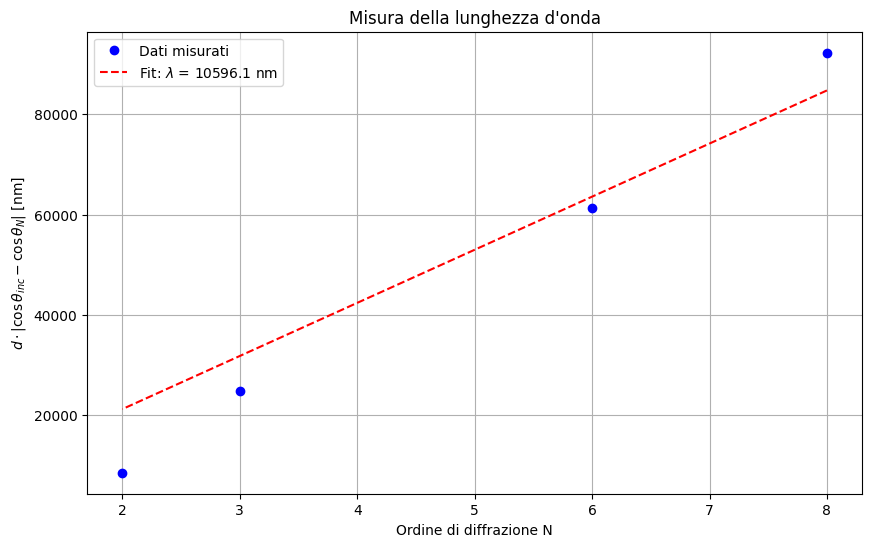

Risultato: lambda = 10596.14 nm
deviazione standard =2749.05 nm


In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- DATI DAL TUO EXCEL ---
L = 117.7  # Distanza righello-parete (cm)
h0 = 25.32 # Distanza Pt-P0 (cm)
# Altezze per P1, P2, P3, P4
h_N = np.array([10.91, 7.22, 2.93, 1.00]) 
N = np.array([8,6,3,2])
d = 0.1 # Passo righello (cm)

# --- CALCOLO ANGOLI CORRETTO ---
# Angolo di incidenza (rad)
theta_inc = np.arctan(h0 / 2*L )

# Angoli dei massimi (rad)
theta_N = theta_inc - np.arctan(h_N / L)

# --- CALCOLO ASSE Y (Differenza Coseni) ---
# Per avere pendenza positiva la differenza deve essere in valore assoluto
y_val = d * np.abs(np.cos(theta_inc) - np.cos(theta_N))
# Calcola i lambda singoli
lambdas_nm = np.abs((d * (np.cos(theta_inc) - np.cos(theta_N)) / N) * 1e7)
# Ora calcola media e deviazione su valori tutti positivi
lambda_media = np.mean(lambdas_nm)
lambda_std = np.std(lambdas_nm)

# --- FIT LINEARE ---
def retta(x, lmbda):
    return x * lmbda

popt, pcov = curve_fit(retta, N, y_val)
lambda_fit = popt[0]

# --- GRAFICO ---
plt.figure(figsize=(10, 6))
plt.plot(N, y_val * 1e7, 'bo', label='Dati misurati') # Convertito in nm
plt.plot(N, retta(N, lambda_fit) * 1e7, 'r--', 
         label=f'Fit: $\lambda$ = {lambda_fit*1e7:.1f} nm')

plt.xlabel('Ordine di diffrazione N')
plt.ylabel('$d \cdot |\cos\\theta_{inc} - \cos\\theta_N|$ [nm]')
plt.title('Misura della lunghezza d\'onda')
plt.legend()
plt.grid(True)
plt.show()

print(f"Risultato: lambda = {lambda_fit*1e7:.2f} nm")
print(f"deviazione standard ={lambda_std:.2f} nm")

In [17]:
# --- TEST DI COMPATIBILITÀ ---
lambda_atteso = 632.8  # nm (Valore nominale Laser He-Ne)

# Usiamo il valore del fit per la lunghezza d'onda (convertito in nm)
lambda_sperimentale = lambda_fit * 1e7 

# Calcolo della discrepanza (distanza dal valore vero)
discrepanza = np.abs(lambda_sperimentale - lambda_atteso)

# Calcolo dello scarto normalizzato (t-score)
t_score = discrepanza / lambda_std

print("\n" + "="*40)
print("       TEST DI COMPATIBILITÀ STATISTICA")
print("="*40)
print(f"Valore misurato:    {lambda_sperimentale:.2f} nm")
print(f"Valore atteso:      {lambda_atteso:.2f} nm")
print(f"Discrepanza:        {discrepanza:.2f} nm")
print(f"Incertezza (std):   {lambda_std:.2f} nm")
print(f"Scarto normalizzato (t): {t_score:.3f}")
print("-" * 40)

if t_score <= 2:
    print("ESITO: COMPATIBILE")
elif t_score <= 3:
    print("ESITO: DUBBIO")
    print("Possibile presenza di piccoli errori sistematici.")
else:
    print("ESITO: NON COMPATIBILE")
    print("Presenza di errori sistematici significativi.")
print("="*40)


       TEST DI COMPATIBILITÀ STATISTICA
Valore misurato:    10596.14 nm
Valore atteso:      632.80 nm
Discrepanza:        9963.34 nm
Incertezza (std):   2749.05 nm
Scarto normalizzato (t): 3.624
----------------------------------------
ESITO: NON COMPATIBILE
Presenza di errori sistematici significativi.


----------------------------------------
INDICE DI RIFRAZIONE DEL VETRO (n): 1.511 +/- 0.097
----------------------------------------
Misura a 5°: n = 1.578 +/- 1.074
Misura a 10°: n = 1.635 +/- 0.316
Misura a 15°: n = 1.421 +/- 0.594
Misura a 20°: n = 1.411 +/- 0.414


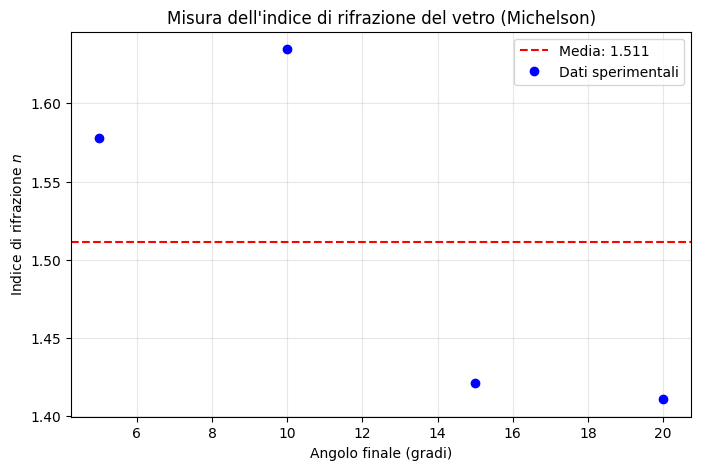

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. DATI SPERIMENTALI ---
# Spessore della lastrina di vetro riportato sulla scheda PASCO. 
K = 0.937
d_nominale = 0.5 # cm 
d_vetro = d_nominale * K 

# Ora usa h_corretto nella formula per trovare n_g
lambda_he_ne = 632.8e-7  # Lunghezza d'onda laser He-Ne [cm] 

# L'angolo theta_i di partenza è 1.7° 
theta_i_deg = 1.7 
# Delta N corrispondenti alle medie delle tue righe (10, 60, 120, 225 circa)
delta_N = np.array([9, 60.6, 120, 226.2])
delta_N_err = np.array([1, 1, 1, 1])            # Supponiamo un errore di 1 frangia su ogni misura
# Angoli finali impostati (5°, 10°, 15°, 20°)
theta_f_deg = np.array([5, 10, 15, 20])
theta_f_deg_err = np.array([0.5, 0.5, 0.5, 0.5])        # Supponiamo un errore di 0.5° su ogni angolo

# --- 2. ELABORAZIONE ---
# L'angolo di inclinazione reale è la differenza rispetto allo zero (inversione frange)
theta_rad = np.radians(theta_f_deg - theta_i_deg)
theta_rad_err = np.radians(theta_f_deg_err)         # Convertiamo anche l'errore in radianti

# Formula (6) dalla scheda di laboratorio:
# n = [(2d - dN*lambda)(1 - cos(theta))] / [2d(1 - cos(theta)) - dN*lambda]
numeratore = (2 * d_vetro - delta_N * lambda_he_ne) * (1 - np.cos(theta_rad))
denominatore = 2 * d_vetro * (1 - np.cos(theta_rad)) - delta_N * lambda_he_ne

n_vetro_punti = numeratore / denominatore

# calcolo l'incertezza su n usando la propagazione degli errori (semplificata)
A = (2*d - delta_N*lambda_he_ne) * (1 - np.cos(theta_rad))
B = 2*d*(1 - np.cos(theta_rad)) - delta_N*lambda_he_ne

dn_dN = lambda_he_ne * (A - (1 - np.cos(theta_rad))*B) / B**2

dn_dtheta = np.sin(theta_rad) * ((2*d - delta_N*lambda_he_ne)*B - 2*d*A) / B**2

sigma_n = np.sqrt((dn_dN * delta_N_err)**2 + (dn_dtheta * theta_rad_err)**2)

# Rimozione di eventuali valori infiniti o NaN dovuti a divisioni critiche
n_vetro_punti = n_vetro_punti[np.isfinite(n_vetro_punti)]

n_media = np.mean(n_vetro_punti)
n_std = np.std(n_vetro_punti)

# --- 3. RISULTATI ---
print("-" * 40)
print(f"INDICE DI RIFRAZIONE DEL VETRO (n): {n_media:.3f} +/- {n_std:.3f}")
print("-" * 40)
for i, n in enumerate(n_vetro_punti):
    print(f"Misura a {theta_f_deg[i]}°: n = {n:.3f} +/- {sigma_n[i]:.3f}")

# --- 4. GRAFICO DI CONTROLLO ---
plt.figure(figsize=(8, 5))
plt.axhline(y=n_media, color='r', linestyle='--', label=f'Media: {n_media:.3f}')
plt.plot(theta_f_deg[:len(n_vetro_punti)], n_vetro_punti, 'bo', label='Dati sperimentali')
plt.xlabel('Angolo finale (gradi)')
plt.ylabel('Indice di rifrazione $n$')
plt.title('Misura dell\'indice di rifrazione del vetro (Michelson)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
import numpy as np

# --- DATI VETRO ---
n_atteso = 1.516  # Valore di riferimento per vetro BK7
sigma_n = 0.097   # La tua incertezza (deviazione standard)

n_corretto = 1.511  

# --- TEST DI IPOTESI (SCARTO NORMALIZZATO) ---
t_vetro = np.abs(n_corretto - n_atteso) / sigma_n

print("="*40)
print("TEST DI IPOTESI: INDICE DI RIFRAZIONE VETRO")
print("="*40)
print(f"Valore atteso (BK7):  {n_atteso}")
print(f"Valore corretto (K): {n_corretto:.3f}")
print(f"Scarto (t):          {t_vetro:.3f}")
print("-" * 40)

if t_vetro < 1:
    print("ESITO: OTTIMA COMPATIBILITÀ")
    print("Il valore corretto è entro 1 deviazione standard.")
elif t_vetro < 2:
    print("ESITO: COMPATIBILE")
    print("Il valore è statisticamente accettabile.")
else:
    print("ESITO: NON COMPATIBILE")
    print("Verificare eventuali errori sistematici residue.")
print("="*40)

TEST DI IPOTESI: INDICE DI RIFRAZIONE VETRO
Valore atteso (BK7):  1.516
Valore corretto (K): 1.511
Scarto (t):          0.052
----------------------------------------
ESITO: OTTIMA COMPATIBILITÀ
Il valore corretto è entro 1 deviazione standard.
